In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Dinesh-Narasimhan/car-price-prediction/main/cars24_20221210.csv"

df = pd.read_csv(url)

df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [2]:
df.columns

Index(['name', 'make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'url', 'createdDate'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 non-null   int64 


In [4]:
df['model'] = df.groupby('model')['price'].transform('mean')

df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,6.427518e+05,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,2.977222e+05,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,6.989960e+05,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,1.493817e+06,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,7.633097e+05,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [5]:
df = df.select_dtypes(include=np.number)

df = df.dropna()

df.head()

,model,year,kilometerdriven,ownernumber,benefits,discountprice,price
0,6.427518e+05,2017,35939,2,13898,47399,607000
1,2.977222e+05,2016,6180,1,12542,2099,326000
2,6.989960e+05,2019,46808,1,13898,26000,640000
3,1.493817e+06,2020,26045,1,9688,143700,1354000
4,7.633097e+05,2017,53056,1,13898,22800,676000


In [6]:
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

In [7]:
from sklearn.linear_model import LinearRegression

X1_train = X_train[['model']]
X1_test = X_test[['model']]

uni_model = LinearRegression()

uni_model.fit(X1_train, y_train)

y_pred_uni = uni_model.predict(X1_test)

print("Coefficient:", uni_model.coef_)
print("Intercept:", uni_model.intercept_)
print("R2 Score:", uni_model.score(X1_test, y_test))

Coefficient: [0.99234963]
Intercept: 4238.786978640244
R2 Score: 0.8260357383069923


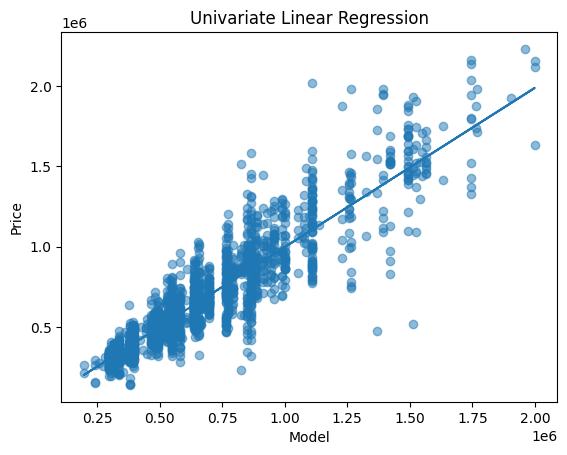

In [8]:
plt.scatter(X1_test, y_test, alpha=0.5)
plt.plot(X1_test, y_pred_uni)

plt.xlabel("Model")
plt.ylabel("Price")

plt.title("Univariate Linear Regression")

plt.show()

In [9]:
multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)
print("R2 Score:", multi_model.score(X_test, y_test))

Coefficients: [ 8.92035518e-01  2.26258325e+04 -6.42101951e-01 -1.32662243e+04
 -1.97308390e+00  4.94242223e-01]
Intercept: -45523445.6691122
R2 Score: 0.869566735419492


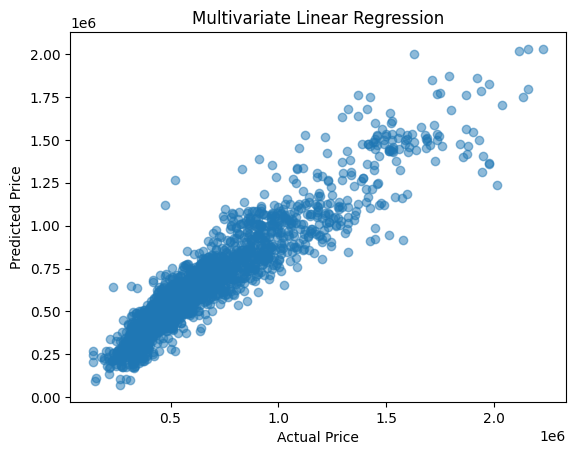

In [10]:
plt.scatter(y_test, y_pred_multi, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Multivariate Linear Regression")

plt.show()

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X_poly_train = X_train[['model']]
X_poly_test = X_test[['model']]

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(
    X_poly_train,
    y_train
)

y_pred_poly = poly_model.predict(
    X_poly_test
)

print(
    "Polynomial R2 Score:",
    poly_model.score(
        X_poly_test,
        y_test
    )
)

Polynomial R2 Score: 0.8260296543994845


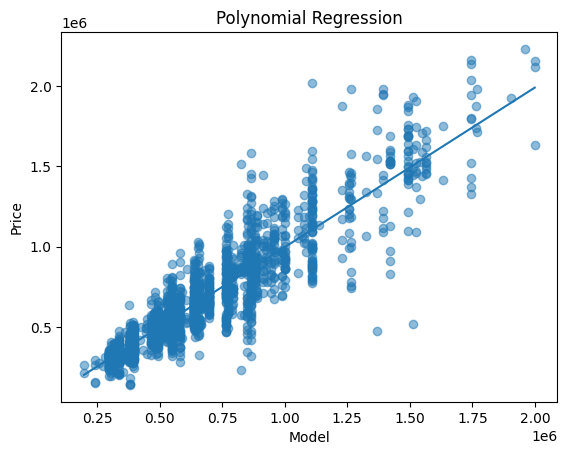

In [12]:
order = np.argsort(
    X_poly_test['model'].values
)

plt.scatter(
    X_poly_test['model'],
    y_test,
    alpha=0.5
)

plt.plot(
    X_poly_test['model'].values[order],
    y_pred_poly[order]
)

plt.xlabel("Model")
plt.ylabel("Price")

plt.title("Polynomial Regression")

plt.show()

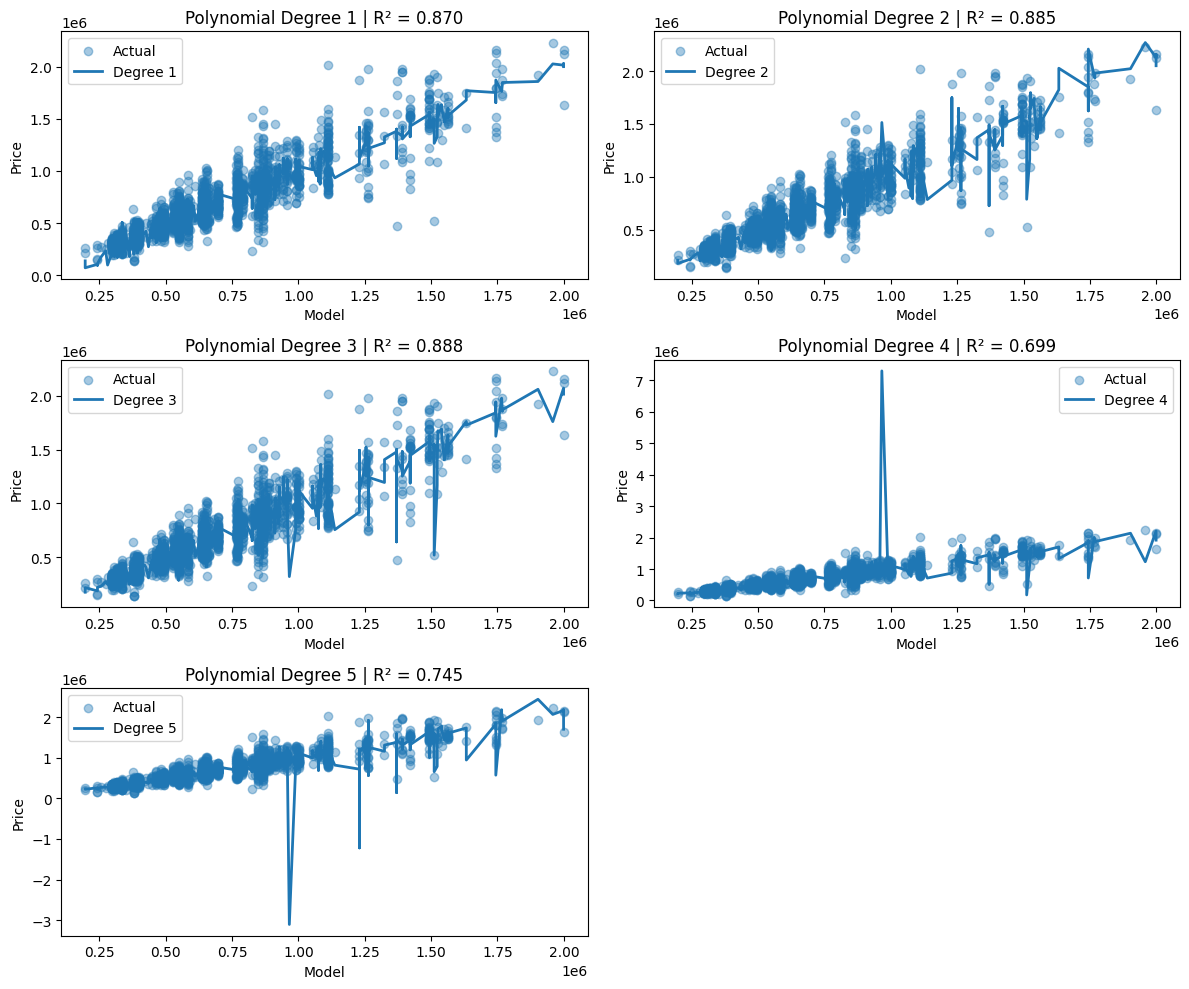

In [14]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 10))

for i, degree in enumerate(degrees, 1):

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()

    poly_model.fit(
        X_train_poly,
        y_train
    )

    y_pred_poly = poly_model.predict(
        X_test_poly
    )

    r2 = poly_model.score(
        X_test_poly,
        y_test
    )

    order = np.argsort(
        X_test['model'].values
    )

    plt.subplot(3, 2, i)

    plt.scatter(
        X_test['model'],
        y_test,
        alpha=0.4,
        label='Actual'
    )

    plt.plot(
        X_test['model'].values[order],
        y_pred_poly[order],
        linewidth=2,
        label=f'Degree {degree}'
    )

    plt.xlabel("Model")
    plt.ylabel("Price")

    plt.title(
        f"Polynomial Degree {degree} | R² = {r2:.3f}"
    )

    plt.legend()

plt.tight_layout()
plt.show()